# Example: Simple Classifier From The Training Manifest

This notebook shows the feature-based baseline path: load the manifest, make a notebook-only balanced training pool, read only `/features/*` from the HDF5 shards, train a very simple classifier, and evaluate it on fresh splits.

For this skeleton the background class is **forced-triggered real data only** and the signal class is simulation. The manifest file itself is not modified.

It intentionally does not read `/waveforms`; time-series models should use the same manifest but load `/waveforms`, `/trace_start_time`, and `/trace_delta_t` instead.

In [14]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path('/fs/ess/PAS2608/alisa/rno_g/TS_ML')
MANIFEST = ROOT / 'ml_dataset/training_manifest.csv'

manifest = pd.read_csv(MANIFEST)
manifest.head()

,file_path,event_index,station,run,event_number,timestamp,trigger_type,label,source_type,split,weight
0,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,0,23,1000,0,1.663969e+09,1,0,0,train,1.0
1,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,1,23,1000,1,1.663969e+09,1,0,0,train,1.0
2,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,2,23,1000,2,1.663969e+09,1,0,0,train,1.0
3,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,3,23,1000,3,1.663969e+09,1,0,0,train,1.0
4,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,4,23,1000,4,1.663969e+09,1,0,0,train,1.0


In [15]:
print('manifest events:', len(manifest))
print('Columns:')
print(list(manifest.columns))
print('By source_type and label from manifest:')
print(pd.crosstab(manifest['source_type'], manifest['label']))
print('Data trigger_type counts:')
print(manifest.loc[manifest['source_type'] == 0, 'trigger_type'].value_counts().sort_index())
print('Sim trigger_type counts:')
print(manifest.loc[manifest['source_type'] == 1, 'trigger_type'].value_counts().sort_index())

manifest events: 236161
Columns:
['file_path', 'event_index', 'station', 'run', 'event_number', 'timestamp', 'trigger_type', 'label', 'source_type', 'split', 'weight']
By source_type and label from manifest:
label             0     1
source_type              
0            234007     0
1                 0  2154
Data trigger_type counts:
trigger_type
1     93897
2     26419
3    113691
Name: count, dtype: int64
Sim trigger_type counts:
trigger_type
-1    2154
Name: count, dtype: int64


In [16]:
RANDOM_SEED = 23
FORCE = 2

# Work on a notebook-only copy. Nothing here writes back to training_manifest.csv.
manifest_work = manifest.copy()

if 'trigger_type' not in manifest_work.columns:
    raise ValueError('Manifest has no trigger_type column. Rebuild it with the updated build_training_manifest.py.')

# Re-label in notebook, without changing the manifest file:
# source_type 0 = real data/noise, source_type 1 = simulation/signal.
manifest_work['label'] = np.where(manifest_work['source_type'] == 1, 1, 0)

# Data/background: only forced-triggered real data.
data_df = manifest_work[
    (manifest_work['source_type'] == 0) &
    (manifest_work['trigger_type'] == FORCE)
].copy()

# Sim/signal: keep all simulation events.
sim_df = manifest_work[manifest_work['source_type'] == 1].copy()

print('forced data events:', len(data_df))
print('sim events:', len(sim_df))

n_each = min(len(data_df), len(sim_df))
if n_each == 0:
    raise ValueError('Need at least one forced data event and one sim event.')
print('Using events per class:', n_each)

data_bal = data_df.sample(n=n_each, random_state=RANDOM_SEED)
sim_bal = sim_df.sample(n=n_each, random_state=RANDOM_SEED)

balanced_manifest = (
    pd.concat([data_bal, sim_bal], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

# Equal event weighting for this classifier baseline.
balanced_manifest['weight'] = 1.0


def assign_stratified_splits(df, train_frac=0.70, val_frac=0.15, seed=23):
    parts = []
    for label, group in df.groupby('label'):
        group = group.sample(frac=1, random_state=seed).copy()
        n = len(group)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        group['split'] = 'test'
        group.iloc[:n_train, group.columns.get_loc('split')] = 'train'
        group.iloc[n_train:n_train + n_val, group.columns.get_loc('split')] = 'val'
        parts.append(group)

    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

balanced_manifest = assign_stratified_splits(balanced_manifest, seed=RANDOM_SEED)

print('Balanced split x label counts:')
print(pd.crosstab(balanced_manifest['split'], balanced_manifest['label']))

forced data events: 26419
sim events: 2154
Using events per class: 2154
Balanced split x label counts:
label     0     1
split            
test    324   324
train  1507  1507
val     323   323


In [17]:
balanced_manifest.head()

,file_path,event_index,station,run,event_number,timestamp,trigger_type,label,source_type,split,weight
0,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,10998,23,1014,10998,1.664053e+09,2,0,0,val,1.0
1,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,726,23,1007,726,1.664000e+09,2,0,0,train,1.0
2,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,969,23,1027,969,1.664144e+09,2,0,0,train,1.0
3,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,3163,23,1031,3163,1.664177e+09,2,0,0,train,1.0
4,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/s...,72,23,6217,0,1.664582e+09,-1,1,1,val,1.0


In [7]:
print('balanced events:', len(balanced_manifest))
print('By split:')
print(balanced_manifest['split'].value_counts())
print('By label:')
print(balanced_manifest['label'].value_counts().sort_index())
print('By split and label:')
print(pd.crosstab(balanced_manifest['split'], balanced_manifest['label']))
print('Trigger types used by class:')
print(pd.crosstab(balanced_manifest['label'], balanced_manifest['trigger_type']))

balanced events: 4308
By split:
split
train    3024
val       738
test      546
Name: count, dtype: int64
By label:
label
0    2154
1    2154
Name: count, dtype: int64
By split and label:
label     0     1
split            
test    201   345
train  1526  1498
val     427   311
Trigger types used by class:
trigger_type    -1     2
label                   
0                0  2154
1             2154     0


## Load Feature Rows

The manifest stores `file_path` plus `event_index`. We group rows by file so each HDF5 shard is opened once. This reads only small feature arrays, not the waveform tensors.

In [18]:
FEATURES = [
    'snr_avg_deep',
    'coherent_snr_deep',
    'max_corr',
    'passed_hit_filter',
]


def resolve_path(path_value):
    path = Path(path_value)
    return path if path.is_absolute() else ROOT / path


def read_h5_rows(dataset, event_idx):
    # h5py fancy indexing requires increasing indices. Restore the manifest order after reading.
    event_idx = np.asarray(event_idx, dtype=np.int64)
    order = np.argsort(event_idx)
    sorted_idx = event_idx[order]
    values_sorted = np.asarray(dataset[sorted_idx])
    values = np.empty_like(values_sorted)
    values[order] = values_sorted
    return values


def load_feature_frame(manifest_df, feature_names=FEATURES):
    parts = []
    for file_path, rows in manifest_df.groupby('file_path', sort=False):
        path = resolve_path(file_path)
        event_idx = rows['event_index'].to_numpy(dtype=np.int64)
        with h5py.File(path, 'r') as h5:
            data = {}
            for name in feature_names:
                ds_path = f'features/{name}'
                if ds_path in h5:
                    data[name] = read_h5_rows(h5[ds_path], event_idx)
                else:
                    data[name] = np.full(len(event_idx), np.nan)
        part = pd.DataFrame(data, index=rows.index)
        parts.append(part)

    features = pd.concat(parts).sort_index()
    meta_cols = [
        'file_path', 'event_index', 'station', 'run', 'event_number', 'timestamp',
        'trigger_type', 'label', 'source_type', 'split', 'weight'
    ]
    return pd.concat(
        [manifest_df[meta_cols].reset_index(drop=True), features.reset_index(drop=True)],
        axis=1,
    )


df = load_feature_frame(balanced_manifest)
df.head()

,file_path,event_index,station,run,event_number,timestamp,trigger_type,label,source_type,split,weight,snr_avg_deep,coherent_snr_deep,max_corr,passed_hit_filter
0,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,10998,23,1014,10998,1.664053e+09,2,0,0,val,1.0,2.591429,2.408056,NaN,0
1,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,726,23,1007,726,1.664000e+09,2,0,0,train,1.0,2.631415,2.301379,NaN,0
2,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,969,23,1027,969,1.664144e+09,2,0,0,train,1.0,2.642810,2.394518,NaN,1
3,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/d...,3163,23,1031,3163,1.664177e+09,2,0,0,train,1.0,2.658999,2.313910,NaN,0
4,/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset/s...,72,23,6217,0,1.664582e+09,-1,1,1,val,1.0,2.751197,2.369333,NaN,0


In [19]:
df[FEATURES].describe()

,snr_avg_deep,coherent_snr_deep,max_corr,passed_hit_filter
count,4308.000000,4308.000000,0.0,4308.000000
mean,6.861269,15.961219,NaN,0.461931
std,11.983715,35.398434,NaN,0.498607
min,1.800173,1.108898,NaN,0.000000
25%,2.625788,2.433317,NaN,0.000000
50%,2.716818,2.732370,NaN,0.000000
75%,4.192005,8.521942,NaN,1.000000
max,122.173050,287.595551,NaN,1.000000


## Train A Minimal Classifier

Default model: Linear Discriminant Analysis (LDA). It is simple, fast, and good for checking that the full data plumbing works.

Set `MODEL_KIND = 'tree'` if you want a tiny decision-tree baseline instead. This is not meant to be the final BDT; it is just a skeleton.

In [20]:
train = df[df['split'] == 'train'].copy()
val = df[df['split'] == 'val'].copy()
test = df[df['split'] == 'test'].copy()

# Use validation during development; reserve test for final checks.
eval_df = val

X_train = train[FEATURES].replace([np.inf, -np.inf], np.nan)
y_train = train['label'].astype(int)
w_train = train['weight'].astype(float)

X_eval = eval_df[FEATURES].replace([np.inf, -np.inf], np.nan)
y_eval = eval_df['label'].astype(int)
w_eval = eval_df['weight'].astype(float)

print('train:', X_train.shape, dict(y_train.value_counts().sort_index()))
print('eval:', X_eval.shape, dict(y_eval.value_counts().sort_index()))

if y_train.nunique() < 2:
    raise ValueError('Training split has fewer than two classes.')
if y_eval.nunique() < 2:
    raise ValueError('Evaluation split has fewer than two classes.')

train: (3014, 4) {0: np.int64(1507), 1: np.int64(1507)}
eval: (646, 4) {0: np.int64(323), 1: np.int64(323)}


In [21]:
MODEL_KIND = 'lda'  # options: 'lda', 'tree'

if MODEL_KIND == 'lda':
    model = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LinearDiscriminantAnalysis(),
    )
elif MODEL_KIND == 'tree':
    model = make_pipeline(
        SimpleImputer(strategy='median'),
        DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED),
    )
else:
    raise ValueError(f'Unknown MODEL_KIND: {MODEL_KIND}')

# We set weights to 1.0 for the balanced skeleton dataset above, so plain fit is enough.
model.fit(X_train, y_train)
score_eval = model.predict_proba(X_eval)[:, 1]
pred_eval = (score_eval >= 0.5).astype(int)

print(model)

/users/PCON0003/anozdrina/venvs/py312-env/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['max_corr']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('lineardiscriminantanalysis', LinearDiscriminantAnalysis())])


/users/PCON0003/anozdrina/venvs/py312-env/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['max_corr']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [22]:
print('accuracy:', accuracy_score(y_eval, pred_eval, sample_weight=w_eval))
if y_eval.nunique() == 2:
    print('ROC AUC:', roc_auc_score(y_eval, score_eval, sample_weight=w_eval))
    print('Average precision:', average_precision_score(y_eval, score_eval, sample_weight=w_eval))
else:
    print('Only one class is present in this eval split; ROC/PR metrics are undefined.')

print('\nConfusion matrix:')
print(confusion_matrix(y_eval, pred_eval, sample_weight=w_eval))
print('\nClassification report:')
print(classification_report(y_eval, pred_eval, sample_weight=w_eval, digits=3))

accuracy: 0.9148606811145511
ROC AUC: 0.9364893749580654
Average precision: 0.9566269436215253

Confusion matrix:
[[305.  18.]
 [ 37. 286.]]

Classification report:
              precision    recall  f1-score   support

           0      0.892     0.944     0.917     323.0
           1      0.941     0.885     0.912     323.0

    accuracy                          0.915     646.0
   macro avg      0.916     0.915     0.915     646.0
weighted avg      0.916     0.915     0.915     646.0



In [28]:
score_eval

array([0.0134879 , 0.0134503 , 0.01339791, 0.0133978 , 0.01349653,
       0.01340176, 0.9923239 , 0.01354602, 0.9971712 , 0.01348914,
       0.99650806, 0.01351089, 0.01352779, 0.01352027, 0.013699  ,
       0.992258  , 0.01349159, 0.9941018 , 0.01353902, 0.99669856,
       0.01353912, 0.9933374 , 0.9922781 , 0.99398065, 0.9922931 ,
       0.01349746, 0.01342674, 0.01357477, 0.01351646, 0.9926093 ,
       0.99247265, 0.01345198, 0.01352192, 0.99219126, 0.0133986 ,
       0.01351107, 0.99887556, 0.01350784, 0.9921799 , 0.9924517 ,
       0.01338851, 0.01348212, 0.99279106, 0.01349842, 0.993508  ,
       0.99748296, 0.9922786 , 0.01348303, 0.9922621 , 0.99221426,
       0.01352437, 0.01350804, 0.01345447, 0.9924711 , 0.01342794,
       0.9947537 , 0.01338523, 0.01354247, 0.996145  , 0.01348997,
       0.01340933, 0.99782526, 0.01354361, 0.9939335 , 0.01346676,
       0.99713874, 0.99414223, 0.01353433, 0.01350894, 0.01339305,
       0.01346872, 0.9927684 , 0.9927878 , 0.01355841, 0.01339

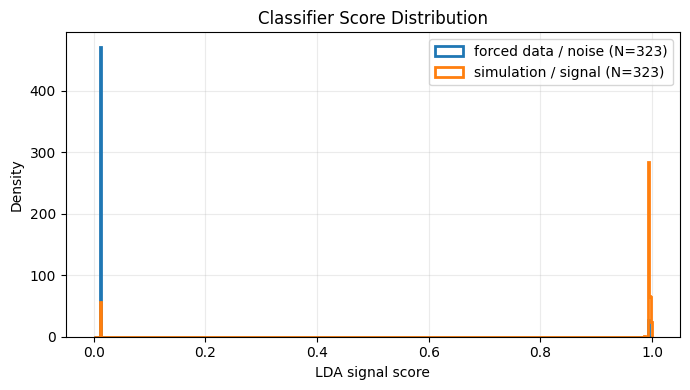

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))

bins = np.linspace(0, 1, 500)

for label, name in [(0, "forced data / noise"), (1, "simulation / signal")]:
    mask = y_eval.to_numpy() == label
    ax.hist(
        score_eval[mask],
        bins=bins,
        histtype="step",
        linewidth=2,
        density=True,
        label=f"{name} (N={mask.sum()})",
    )

ax.set_xlabel("LDA signal score")
ax.set_ylabel("Density")
ax.set_title("Classifier Score Distribution")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

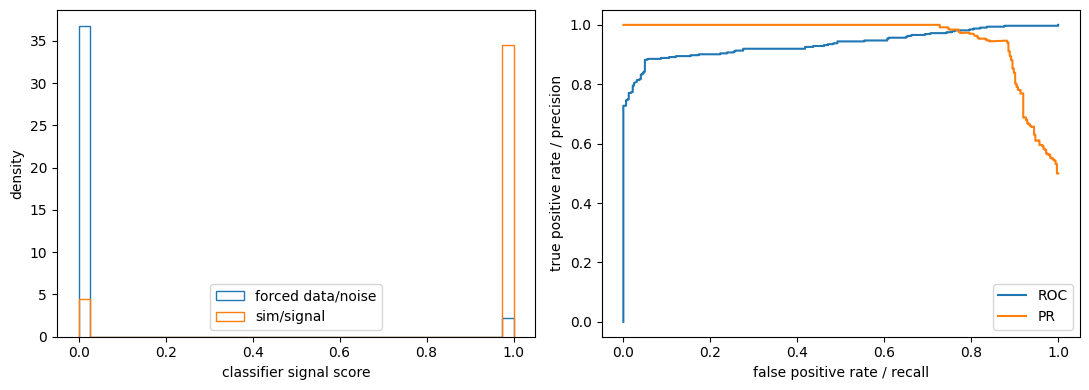

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bins = np.linspace(0, 1, 40)
for label, name in [(0, 'forced data/noise'), (1, 'sim/signal')]:
    mask = y_eval.to_numpy() == label
    if mask.any():
        axes[0].hist(score_eval[mask], bins=bins, histtype='step', density=True, label=name)
axes[0].set_xlabel('classifier signal score')
axes[0].set_ylabel('density')
axes[0].legend()

if y_eval.nunique() == 2:
    fpr, tpr, _ = roc_curve(y_eval, score_eval, sample_weight=w_eval)
    precision, recall, _ = precision_recall_curve(y_eval, score_eval, sample_weight=w_eval)
    axes[1].plot(fpr, tpr, label='ROC')
    axes[1].plot(recall, precision, label='PR')
    axes[1].set_xlabel('false positive rate / recall')
    axes[1].set_ylabel('true positive rate / precision')
    axes[1].legend()
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Need both classes in eval split', ha='center', va='center')

fig.tight_layout()

## Optional: Permutation Sanity Check

This is just a quick check that changing one input feature changes the score. It is not a careful feature-importance study.

In [24]:
if y_eval.nunique() == 2:
    rng = np.random.default_rng(23)
    baseline_auc = roc_auc_score(y_eval, score_eval, sample_weight=w_eval)
    drops = []
    for feature in FEATURES:
        X_perm = X_eval.copy()
        X_perm[feature] = rng.permutation(X_perm[feature].to_numpy())
        perm_score = model.predict_proba(X_perm)[:, 1]
        perm_auc = roc_auc_score(y_eval, perm_score, sample_weight=w_eval)
        drops.append({'feature': feature, 'auc_drop': baseline_auc - perm_auc})
    importance = pd.DataFrame(drops).sort_values('auc_drop', ascending=False)
    display(importance)
else:
    print('Need both classes in eval split for permutation AUC importance.')

/users/PCON0003/anozdrina/venvs/py312-env/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['max_corr']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/users/PCON0003/anozdrina/venvs/py312-env/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['max_corr']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/users/PCON0003/anozdrina/venvs/py312-env/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['max_corr']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/users/PCON0003/anozdrina/venvs/py312-env/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['max_corr']. At least one 

,feature,auc_drop
3,passed_hit_filter,0.244774
1,coherent_snr_deep,0.029671
0,snr_avg_deep,0.000278
2,max_corr,0.000000


## Next Steps

- Add more features under `/features` if you want a stronger BDT baseline.
- Replace the skeleton model with XGBoost, LightGBM, TMVA, or scikit-learn boosting when the data plumbing looks right.
- Try different data trigger pools by changing the filter above, e.g. `trigger_type == 3` for RADIANT.
- Use the same balanced manifest logic for a waveform loader, but read `/waveforms` instead of `/features/*`.
- Keep train/validation/test splits fixed across BDT and time-series models for a fair comparison.